# Chapter 5: The Fundamental Group

**Source span.** Armstrong, *Basic Topology*, Chapter 5, printed pp. 87-118; PDF pp. 98-128 in `Basic-Topology/armstrong-basic-topology.pdf`.

**Chapter question.** How can a continuously moving loop become an algebraic object, and how does that object obstruct maps that look geometrically plausible?

**Chapter goal.** Build the fundamental group from based loops, compute it in the first model spaces, and use it as a visual invariant for fixed-point, separation, and surface-boundary arguments.


## Visualization Storyboard And Library Routing

| Storyboard item | Representation | Library route | Artifacts | Check |
| --- | --- | --- | --- | --- |
| Homotopy of based loops | Homotopy square plus winding tracks | Matplotlib | `figures/loop-homotopy-winding.png` | Equal winding degree |
| Loop product group laws | Interval reparameterization and inverse fold | Matplotlib + word reducer | `figures/loop-product-group-laws.png` | Associativity and inverse word checks |
| Basepoints and induced maps | Functor diagram plus conjugation path | NetworkX + Matplotlib | `figures/concept-dependency-map.png`, `figures/induced-map-basepoint-diagram.png` | Circle degrees multiply under composition |
| Circle calculation | Covering line and lifted helices | Matplotlib + Plotly | `figures/circle-lift-degree.png`, `html/circle-covering-degree-lab.html` | Lift endpoint equals winding number |
| Wedge/free group | Rose graph and Cayley fragment | NetworkX + Pandas | `figures/wedge-free-group-cayley.png`, `tables/free-word-reductions.csv` | Free reduction is idempotent |
| Surface-friendly computations | Torus loops, annulus retraction, presentation ledger | Plotly + SymPy | `html/torus-generators.html`, `figures/deformation-retraction-annulus.png`, `figures/surface-generator-polygons.png`, `tables/presentation-invariants.csv` | Smith normal form matches rank/torsion targets |
| Brouwer obstruction | Retraction geometry and group diagram | Matplotlib + SymPy | `figures/brouwer-retraction-obstruction.png` | `Z -> 0 -> Z` is not identity |
| Separation and boundary | Sampled complement components and half-disc obstruction | Shapely + NetworkX + Matplotlib | `figures/plane-separation-grid-check.png`, `figures/surface-boundary-obstruction.png` | Closed curve sample has two components; arc sample has one |


In [1]:
from pathlib import Path
import sys

def find_book_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = [resolved, *resolved.parents]
    candidates += [resolved / "Basic-Topology", *[parent / "Basic-Topology" for parent in resolved.parents]]
    for candidate in candidates:
        if ((candidate / "AGENTS.md").exists() and (candidate / "scripts" / "validate_bt_course.py").exists() and (candidate / "utils").exists()):
            return candidate
    raise RuntimeError("Could not locate Basic-Topology course root")

BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
UNIT = "chapter-05"
SOURCE_SPAN = {"printed": "87-118", "pdf": "98-128"}
NOTEBOOK_PATH = BOOK_ROOT / "chapter-05-the-fundamental-group" / "05-the-fundamental-group.ipynb"
print(f"Course root: {BOOK_ROOT}")
SOURCE_SPAN


Course root: D:\Geometry\Basic-Topology


{'printed': '87-118', 'pdf': '98-128'}

In [2]:
import itertools
import json
import math
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from shapely.geometry import LineString, Point
from sympy import Matrix, ZZ, eye, zeros
from sympy.matrices.normalforms import smith_normal_form

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 130, "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
PALETTE = {"ink":"#1f2937","muted":"#6b7280","blue":"#2563eb","green":"#059669","red":"#dc2626","amber":"#d97706","purple":"#7c3aed","teal":"#0f766e","light_blue":"#dbeafe","light_green":"#dcfce7","light_amber":"#fef3c7","light_red":"#fee2e2","panel":"#f8fafc"}
artifact_paths = []

def register(path: Path) -> Path:
    path = Path(path)
    artifact_paths.append(path)
    return path

def book_rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()

def inverse_letter(letter: str) -> str:
    return letter.upper() if letter.islower() else letter.lower()

def reduce_word(word):
    stack = []
    for letter in tuple(word):
        if stack and inverse_letter(letter) == stack[-1]:
            stack.pop()
        else:
            stack.append(letter)
    return tuple(stack)

def inverse_word(word):
    return tuple(inverse_letter(letter) for letter in reversed(tuple(word)))

def multiply_words(*words):
    return reduce_word(tuple(itertools.chain.from_iterable(tuple(w) for w in words)))

def word_to_string(word) -> str:
    word = tuple(word)
    return "1" if not word else " ".join(word)

def parse_word(text: str):
    text = text.strip()
    return tuple() if text in {"", "1"} else tuple(text.split())

def exponent_vector(word, generators=("a", "b")):
    counts = {g: 0 for g in generators}
    for letter in tuple(word):
        lower = letter.lower()
        if lower in counts:
            counts[lower] += 1 if letter.islower() else -1
    return [counts[g] for g in generators]

def relation_matrix(generators, relators):
    if not relators:
        return Matrix.zeros(0, len(generators))
    return Matrix([exponent_vector(relator, generators) for relator in relators])

def abelianization_summary(generators, relators):
    matrix = relation_matrix(generators, relators)
    if len(generators) == 0:
        return {"rank": 0, "torsion": [], "relation_matrix": []}
    if matrix.rows == 0:
        return {"rank": len(generators), "torsion": [], "relation_matrix": []}
    smith = smith_normal_form(matrix, domain=ZZ)
    diagonal = [abs(int(smith[i, i])) for i in range(min(smith.rows, smith.cols)) if abs(int(smith[i, i]))]
    return {"rank": int(len(generators) - len(diagonal)), "torsion": [d for d in diagonal if d > 1], "relation_matrix": [[int(x) for x in row] for row in matrix.tolist()]}

def describe_abelianization(summary):
    rank, torsion = summary["rank"], summary["torsion"]
    if rank == 0 and not torsion:
        return "0"
    pieces = ["Z" if rank == 1 else f"Z^{rank}"] if rank else []
    pieces.extend(f"Z/{n}" for n in torsion)
    return " x ".join(pieces)

def winding_number(points: np.ndarray) -> int:
    angles = np.unwrap(np.angle(points[:, 0] + 1j * points[:, 1]))
    return int(round((angles[-1] - angles[0]) / (2 * np.pi)))

def save_registered_matplotlib(fig, filename: str, *, kind="figures", dpi=170):
    path = save_matplotlib(fig, UNIT, kind, filename, dpi=dpi)
    plt.close(fig)
    return register(path)


## Computational Translation Guide

A based loop is represented here by a sampled path or by a word in named generators. A homotopy of based loops is represented by a square whose horizontal slices are loops and whose two vertical sides stay at the basepoint. Passing to homotopy classes turns concatenation into a group operation because time reparameterizations and backtracking become invisible.

| Book idea | Computational stand-in |
| --- | --- |
| Homotopy rel endpoints | A two-parameter family with fixed side conditions |
| Product of loops | Concatenate parameter intervals, then ignore harmless time changes |
| Inverse loop | Traverse the sampled path or word backward with inverse letters |
| Basepoint change | Conjugate a loop by a chosen path between basepoints |
| Induced homomorphism | Push a loop through a map; for `S^1 -> S^1`, multiply degree |
| Fundamental group of `S^1` | Lift to `R`; endpoint integer is the class |
| Wedge of circles | Free reduction of loop words |
| Surface examples | Generators from edge loops, relators from side identifications |
| Retraction obstruction | A map identity on a subspace would force a surjection on `pi_1` |


## Proof Dependency Map

The chapter builds one mechanism and then reuses it. Homotopy rel endpoints makes loop classes; loop classes form a group; maps induce homomorphisms; computations turn geometric questions into group-level obstructions.

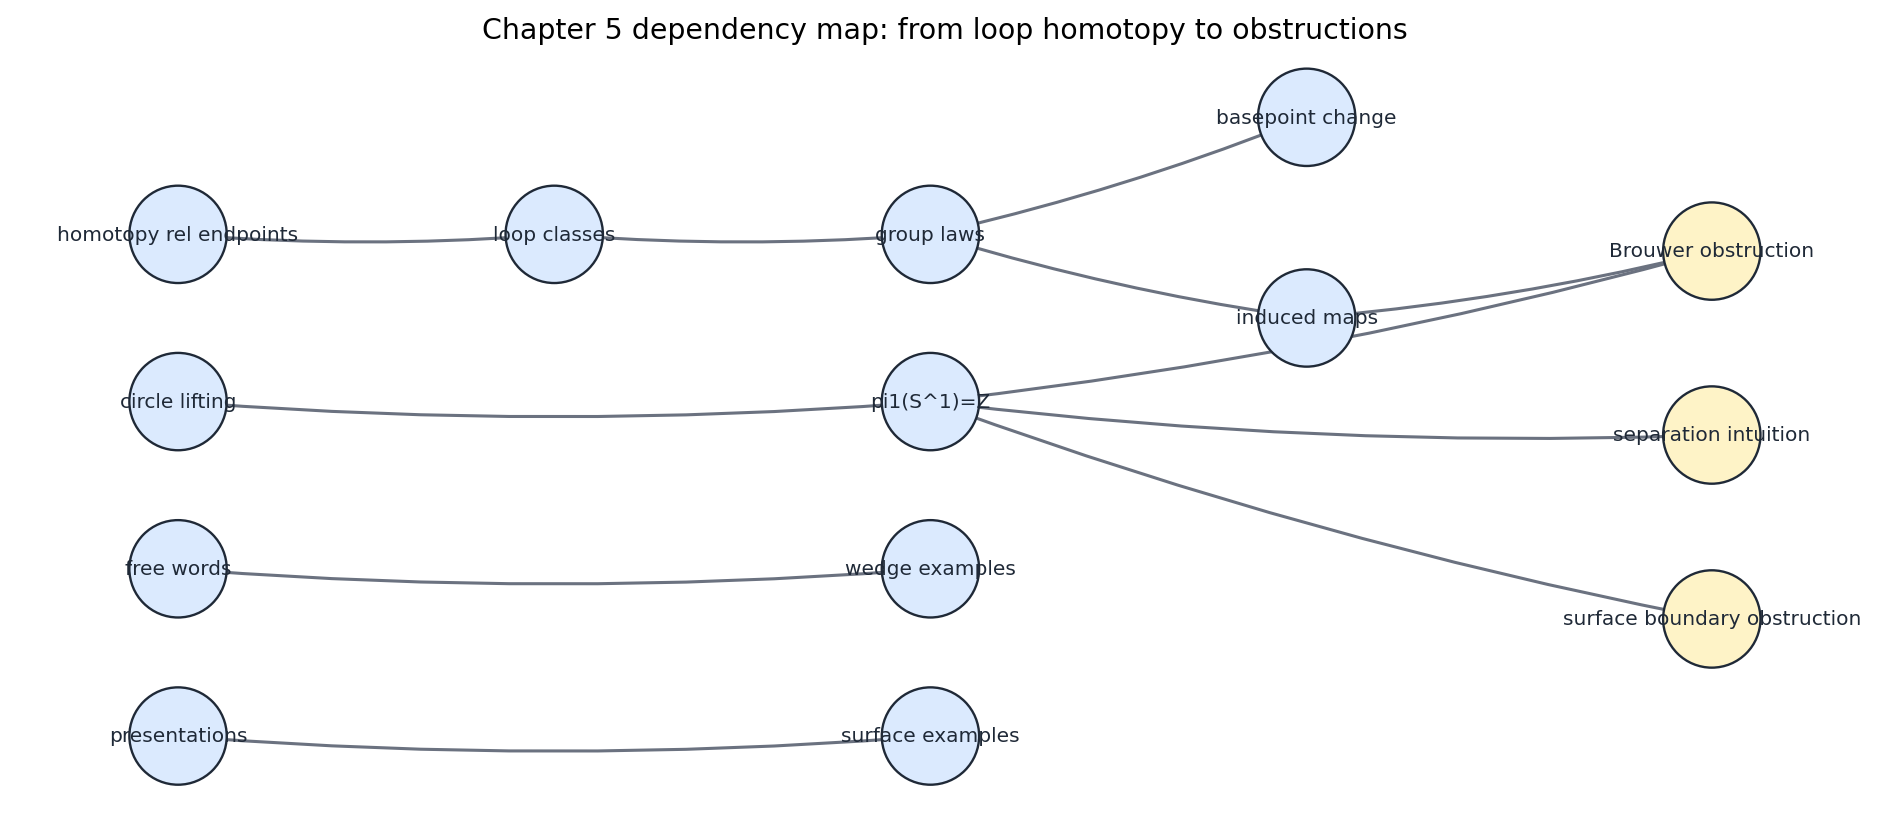

In [3]:
dependency_edges = [
    ("homotopy rel endpoints", "loop classes"),
    ("loop classes", "group laws"),
    ("group laws", "basepoint change"),
    ("group laws", "induced maps"),
    ("circle lifting", "pi1(S^1)=Z"),
    ("free words", "wedge examples"),
    ("presentations", "surface examples"),
    ("pi1(S^1)=Z", "Brouwer obstruction"),
    ("pi1(S^1)=Z", "separation intuition"),
    ("pi1(S^1)=Z", "surface boundary obstruction"),
    ("induced maps", "Brouwer obstruction"),
]
DG = nx.DiGraph(dependency_edges)
levels = {
    "homotopy rel endpoints": (0, 2), "circle lifting": (0, 1), "free words": (0, 0), "presentations": (0, -1),
    "loop classes": (1.3, 2), "group laws": (2.6, 2), "basepoint change": (3.9, 2.7), "induced maps": (3.9, 1.5),
    "pi1(S^1)=Z": (2.6, 1), "wedge examples": (2.6, 0), "surface examples": (2.6, -1),
    "Brouwer obstruction": (5.3, 1.9), "separation intuition": (5.3, 0.8), "surface boundary obstruction": (5.3, -0.3),
}
fig, ax = plt.subplots(figsize=(11, 4.7), constrained_layout=True)
node_colors = [PALETTE["light_blue"] if "obstruction" not in n and "intuition" not in n else PALETTE["light_amber"] for n in DG.nodes]
nx.draw_networkx_nodes(DG, levels, ax=ax, node_size=1700, node_color=node_colors, edgecolors=PALETTE["ink"], linewidths=1.0)
nx.draw_networkx_edges(DG, levels, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.3, edge_color=PALETTE["muted"], connectionstyle="arc3,rad=0.04")
nx.draw_networkx_labels(DG, levels, ax=ax, font_size=8.5, font_color=PALETTE["ink"])
ax.set_axis_off()
ax.set_title("Chapter 5 dependency map: from loop homotopy to obstructions")
concept_map_path = save_registered_matplotlib(fig, "concept-dependency-map.png")
display_artifact(concept_map_path, width=930)


## Loop Homotopy: Keep The Basepoint Fixed

A based homotopy is a square: the bottom edge is `alpha`, the top edge is `beta`, and both vertical sides stay at the basepoint. The lift view shows why a loop that goes forward twice and backward once has the same circle class as a single forward loop: both lifted tracks start at `0` and end at `1`.

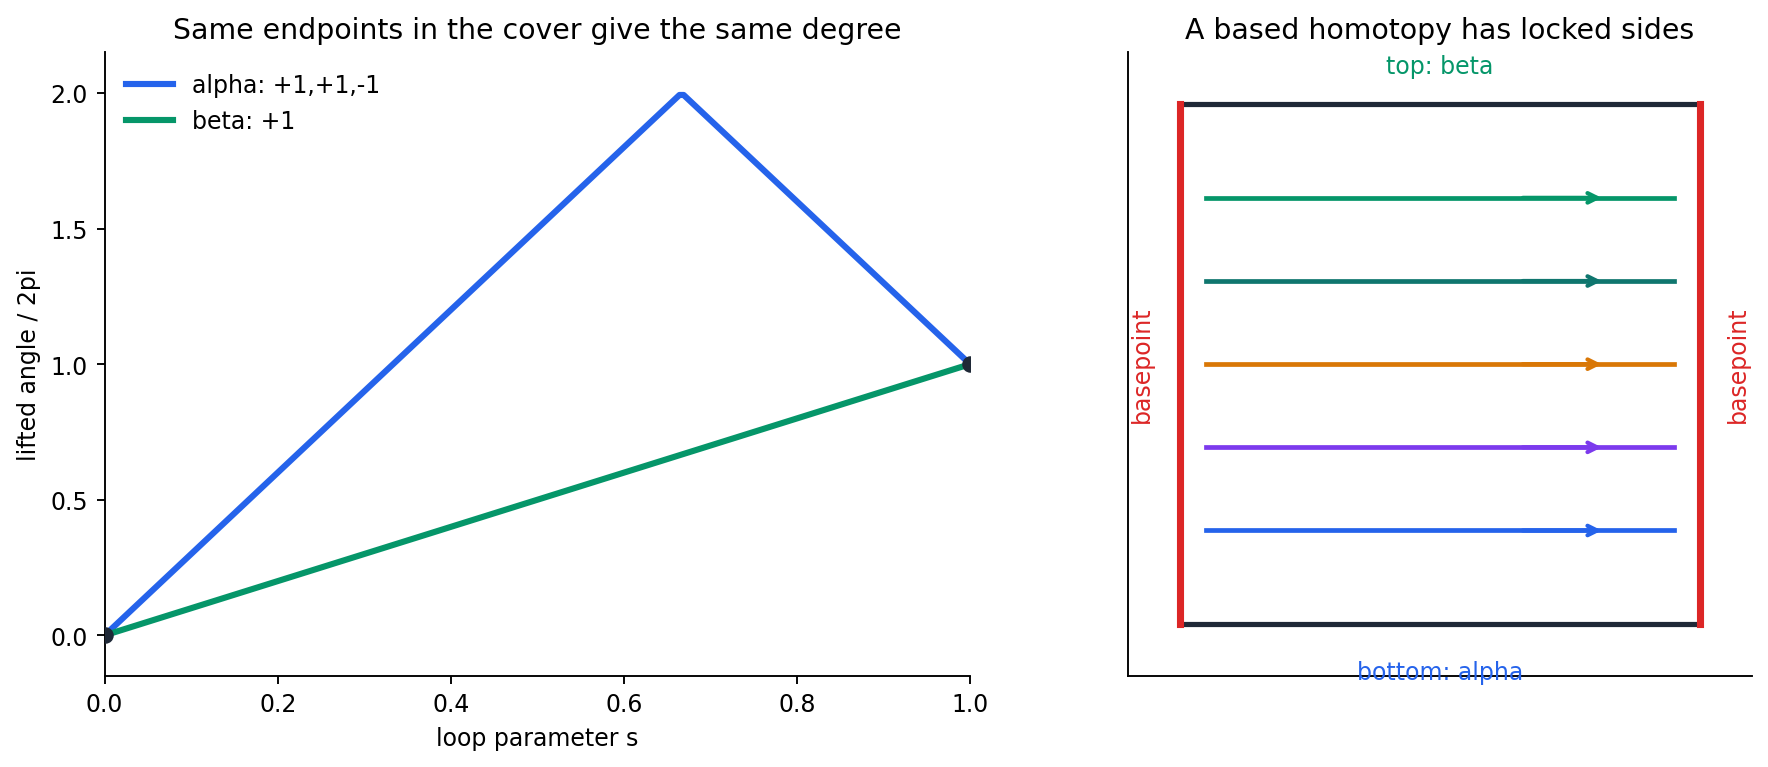

{'alpha_forward_forward_backward': 1, 'beta_single_forward': 1}

In [4]:
def angle_path_from_turns(turns, samples_per_piece=140):
    s_values, angle_values, current_angle = [], [], 0.0
    for piece, turn in enumerate(turns):
        local = np.linspace(0, 1, samples_per_piece, endpoint=piece == len(turns) - 1)
        if piece:
            local = local[1:]
        s_values.extend((piece + local) / len(turns))
        angle_values.extend(current_angle + 2 * np.pi * turn * local)
        current_angle += 2 * np.pi * turn
    return np.array(s_values), np.array(angle_values)

s_alpha, theta_alpha = angle_path_from_turns([1, 1, -1])
s_beta, theta_beta = angle_path_from_turns([1])
alpha_points = np.column_stack([np.cos(theta_alpha), np.sin(theta_alpha)])
beta_points = np.column_stack([np.cos(theta_beta), np.sin(theta_beta)])
loop_degree_checks = {"alpha_forward_forward_backward": winding_number(alpha_points), "beta_single_forward": winding_number(beta_points)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
ax = axes[0]
ax.plot(s_alpha, theta_alpha / (2 * np.pi), color=PALETTE["blue"], lw=2.6, label="alpha: +1,+1,-1")
ax.plot(s_beta, theta_beta / (2 * np.pi), color=PALETTE["green"], lw=2.6, label="beta: +1")
ax.scatter([0, 1], [0, 1], color=PALETTE["ink"], zorder=5)
ax.set(xlabel="loop parameter s", ylabel="lifted angle / 2pi", title="Same endpoints in the cover give the same degree", xlim=(0, 1), ylim=(-0.15, 2.15))
ax.legend(loc="upper left", frameon=False)

ax = axes[1]
ax.set_aspect("equal")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, lw=2.2, color=PALETTE["ink"]))
for t, color in zip(np.linspace(0.18, 0.82, 5), [PALETTE["blue"], PALETTE["purple"], PALETTE["amber"], PALETTE["teal"], PALETTE["green"]]):
    ax.plot([0.05, 0.95], [t, t], color=color, lw=2.0)
    ax.annotate("", xy=(0.82, t), xytext=(0.65, t), arrowprops={"arrowstyle": "->", "color": color, "lw": 1.8})
ax.plot([0, 0], [0, 1], color=PALETTE["red"], lw=3)
ax.plot([1, 1], [0, 1], color=PALETTE["red"], lw=3)
ax.text(0.5, -0.07, "bottom: alpha", ha="center", va="top", color=PALETTE["blue"])
ax.text(0.5, 1.05, "top: beta", ha="center", va="bottom", color=PALETTE["green"])
ax.text(-0.05, 0.5, "basepoint", rotation=90, ha="right", va="center", color=PALETTE["red"])
ax.text(1.05, 0.5, "basepoint", rotation=90, ha="left", va="center", color=PALETTE["red"])
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("A based homotopy has locked sides")
loop_homotopy_path = save_registered_matplotlib(fig, "loop-homotopy-winding.png")
display_artifact(loop_homotopy_path, width=920)
loop_degree_checks


## From Loop Multiplication To A Group

Concatenation of raw loops is sensitive to the clock. After quotienting by homotopy rel endpoints, the clock can be stretched or compressed. The first panel compares the two schedules for `(alpha beta) gamma` and `alpha (beta gamma)`. The second panel shows the inverse loop as backtracking.

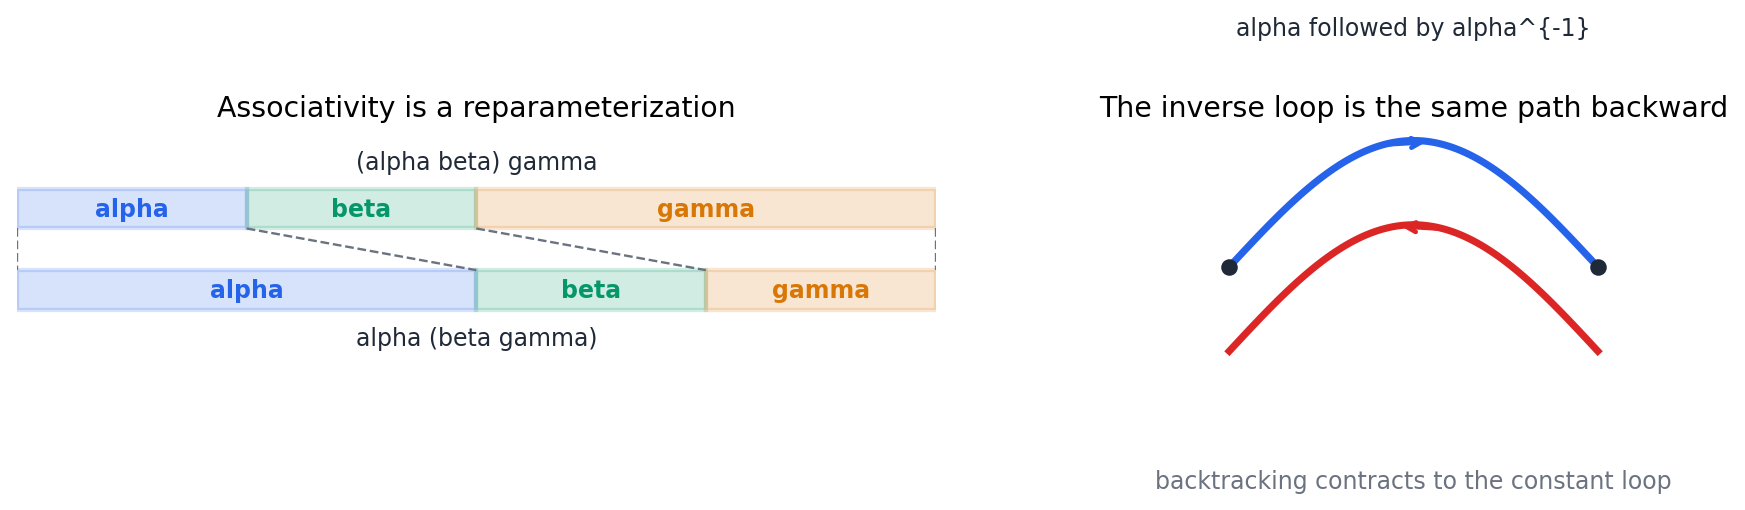

{'associativity_words_match': True,
 'inverse_backtracking_reduces_to_identity': True,
 'identity_left': True}

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0, 2); ax.axis("off")
for y, segments, title in [
    (1.15, [(0, .25, "alpha", "blue"), (.25, .5, "beta", "green"), (.5, 1, "gamma", "amber")], "(alpha beta) gamma"),
    (.45, [(0, .5, "alpha", "blue"), (.5, .75, "beta", "green"), (.75, 1, "gamma", "amber")], "alpha (beta gamma)"),
]:
    for start, end, label, key in segments:
        color = PALETTE[key]
        ax.add_patch(patches.Rectangle((start, y), end - start, .34, facecolor=color, alpha=.18, edgecolor=color, lw=1.8))
        ax.text((start + end) / 2, y + .17, label, ha="center", va="center", color=color, weight="bold")
    ax.text(.5, y + .57 if y > 1 else y - .25, title, ha="center", va="center", color=PALETTE["ink"])
for x1, x2 in [(0, 0), (.25, .5), (.5, .75), (1, 1)]:
    ax.plot([x1, x2], [1.15, .79], color=PALETTE["muted"], ls="--", lw=1)
ax.set_title("Associativity is a reparameterization")

ax = axes[1]
ax.set_aspect("equal"); ax.axis("off")
t = np.linspace(0, 1, 120)
curve = np.column_stack([.15 + .7 * t, .5 + .24 * np.sin(np.pi * t)])
ax.plot(curve[:, 0], curve[:, 1], color=PALETTE["blue"], lw=3)
ax.plot(curve[::-1, 0], curve[::-1, 1] - .16, color=PALETTE["red"], lw=3)
ax.scatter([curve[0, 0], curve[-1, 0]], [curve[0, 1], curve[-1, 1]], color=PALETTE["ink"], zorder=5)
ax.annotate("", xy=curve[65], xytext=curve[50], arrowprops={"arrowstyle": "->", "color": PALETTE["blue"], "lw": 2})
ax.annotate("", xy=(curve[::-1][65, 0], curve[::-1][65, 1] - .16), xytext=(curve[::-1][50, 0], curve[::-1][50, 1] - .16), arrowprops={"arrowstyle": "->", "color": PALETTE["red"], "lw": 2})
ax.text(.5, .94, "alpha followed by alpha^{-1}", ha="center", color=PALETTE["ink"])
ax.text(.5, .08, "backtracking contracts to the constant loop", ha="center", color=PALETTE["muted"])
ax.set_title("The inverse loop is the same path backward")
group_law_path = save_registered_matplotlib(fig, "loop-product-group-laws.png")
assoc_left = multiply_words(multiply_words(("a",), ("b",)), ("c",))
assoc_right = multiply_words(("a",), multiply_words(("b",), ("c",)))
backtrack = multiply_words(("a", "b"), inverse_word(("a", "b")))
group_law_checks = {"associativity_words_match": assoc_left == assoc_right == ("a", "b", "c"), "inverse_backtracking_reduces_to_identity": backtrack == tuple(), "identity_left": multiply_words(tuple(), ("a", "B", "b")) == ("a",)}
display_artifact(group_law_path, width=920)
group_law_checks


## Basepoints And Induced Maps

A basepoint is not cosmetic. When a path `u` moves the basepoint, a loop is read after walking along `u`, running the loop, and walking back. Algebraically that is conjugation. A continuous map sends based loops to based loops, so it induces a homomorphism on fundamental groups.

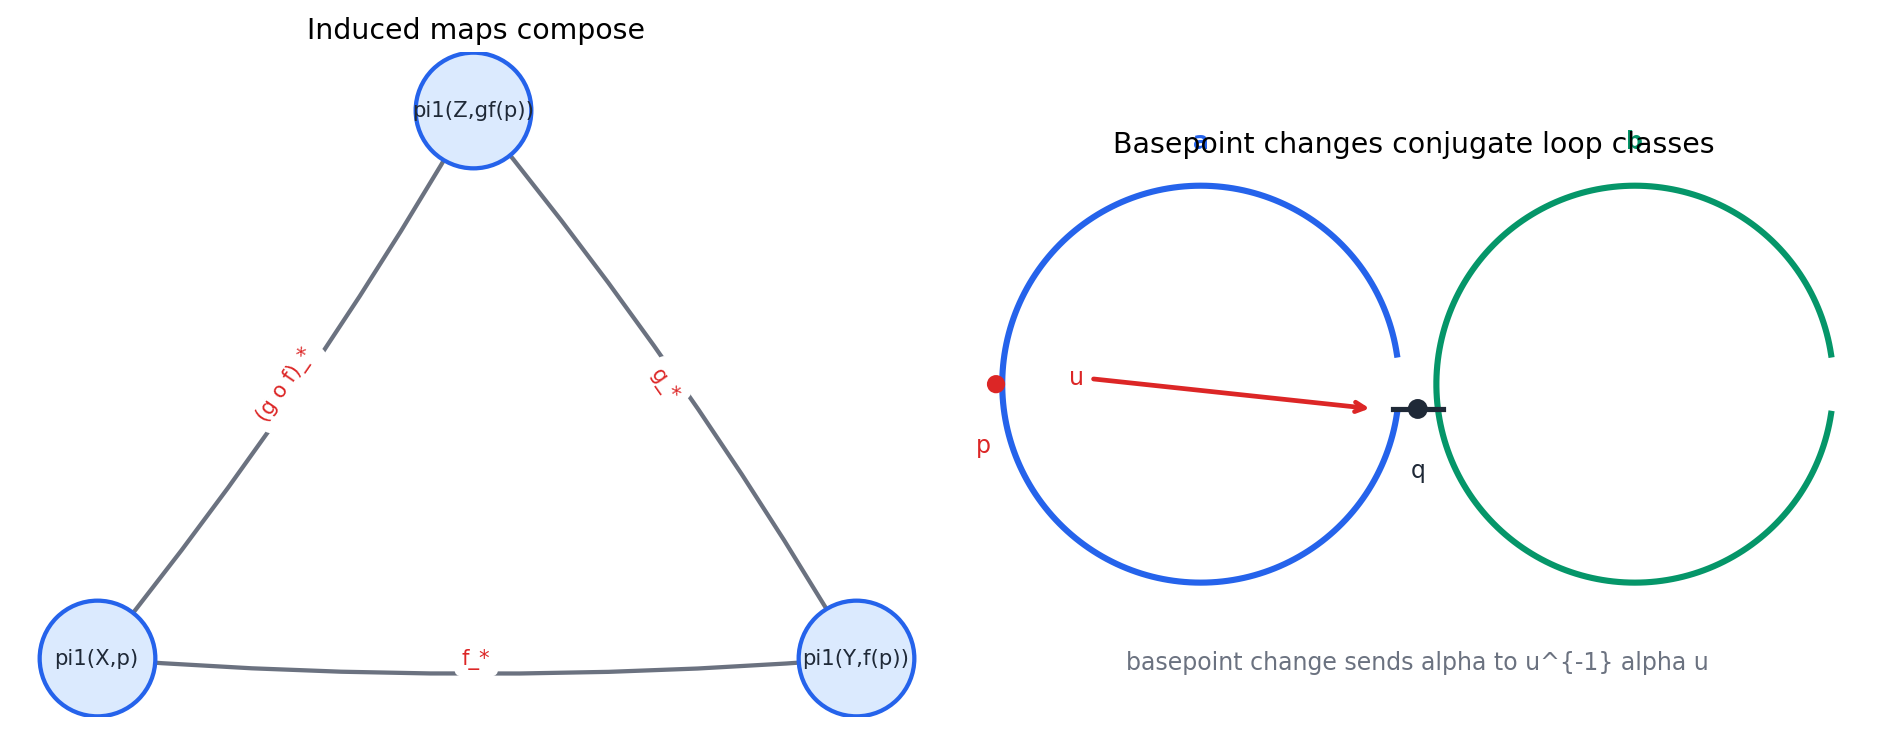

,first_map_degree,second_map_degree,composition_degree,homomorphism_composition_ok
0,-2,3,-6,True
1,2,5,10,True
2,0,7,0,True
3,1,-4,-4,True


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
ax = axes[0]
G = nx.DiGraph()
G.add_edges_from([("pi1(X,p)", "pi1(Y,f(p))", {"label": "f_*"}), ("pi1(Y,f(p))", "pi1(Z,gf(p))", {"label": "g_*"}), ("pi1(X,p)", "pi1(Z,gf(p))", {"label": "(g o f)_*"})])
pos = {"pi1(X,p)": (0, 0), "pi1(Y,f(p))": (1.25, 0), "pi1(Z,gf(p))": (.62, .9)}
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2400, node_color=PALETTE["light_blue"], edgecolors=PALETTE["blue"], linewidths=1.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color=PALETTE["ink"])
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.8, edge_color=PALETTE["muted"], connectionstyle="arc3,rad=0.04")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"), ax=ax, font_size=9, font_color=PALETTE["red"])
ax.set_title("Induced maps compose"); ax.axis("off")

ax = axes[1]
ax.set_aspect("equal"); ax.axis("off")
angles = np.linspace(.15, 2 * np.pi - .15, 220)
left = np.column_stack([-.35 + .32 * np.cos(angles), .04 + .32 * np.sin(angles)])
right = np.column_stack([.35 + .32 * np.cos(angles), .04 + .32 * np.sin(angles)])
ax.plot(left[:, 0], left[:, 1], color=PALETTE["blue"], lw=2.6)
ax.plot(right[:, 0], right[:, 1], color=PALETTE["green"], lw=2.6)
ax.plot([-.04, .04], [0, 0], color=PALETTE["ink"], lw=2.2)
ax.scatter([0, -.68], [0, .04], s=[55, 45], color=[PALETTE["ink"], PALETTE["red"]], zorder=5)
ax.annotate("u", xy=(-.07, 0), xytext=(-.55, .04), arrowprops={"arrowstyle": "->", "lw": 2, "color": PALETTE["red"]}, color=PALETTE["red"], ha="center")
ax.text(0, -.11, "q", ha="center", color=PALETTE["ink"])
ax.text(-.70, -.07, "p", ha="center", color=PALETTE["red"])
ax.text(-.35, .42, "a", ha="center", color=PALETTE["blue"], weight="bold")
ax.text(.35, .42, "b", ha="center", color=PALETTE["green"], weight="bold")
ax.text(0, -.42, "basepoint change sends alpha to u^{-1} alpha u", ha="center", color=PALETTE["muted"])
ax.set_title("Basepoint changes conjugate loop classes")
induced_path = save_registered_matplotlib(fig, "induced-map-basepoint-diagram.png")

basepoint_path = ("u",)
loop_at_p = ("a", "b", "A")
conjugated_loop = multiply_words(inverse_word(basepoint_path), loop_at_p, basepoint_path)
degree_map_checks = []
for m, n_value in [(-2, 3), (2, 5), (0, 7), (1, -4)]:
    degree_map_checks.append({"first_map_degree": m, "second_map_degree": n_value, "composition_degree": m * n_value, "homomorphism_composition_ok": (n_value * (m * 1)) == ((n_value * m) * 1)})
basepoint_induced_checks = {"loop_at_old_basepoint": word_to_string(loop_at_p), "conjugated_loop_at_new_basepoint": word_to_string(conjugated_loop), "degree_map_checks": degree_map_checks}
display_artifact(induced_path, width=920)
pd.DataFrame(degree_map_checks)


## Computing `pi_1(S^1)` With Lifts

The exponential map `R -> S^1` converts a loop problem into an endpoint problem. A loop based at `1` lifts uniquely after choosing the starting lift `0`; the endpoint must be an integer. That integer is the degree, and it classifies based loops in the circle.

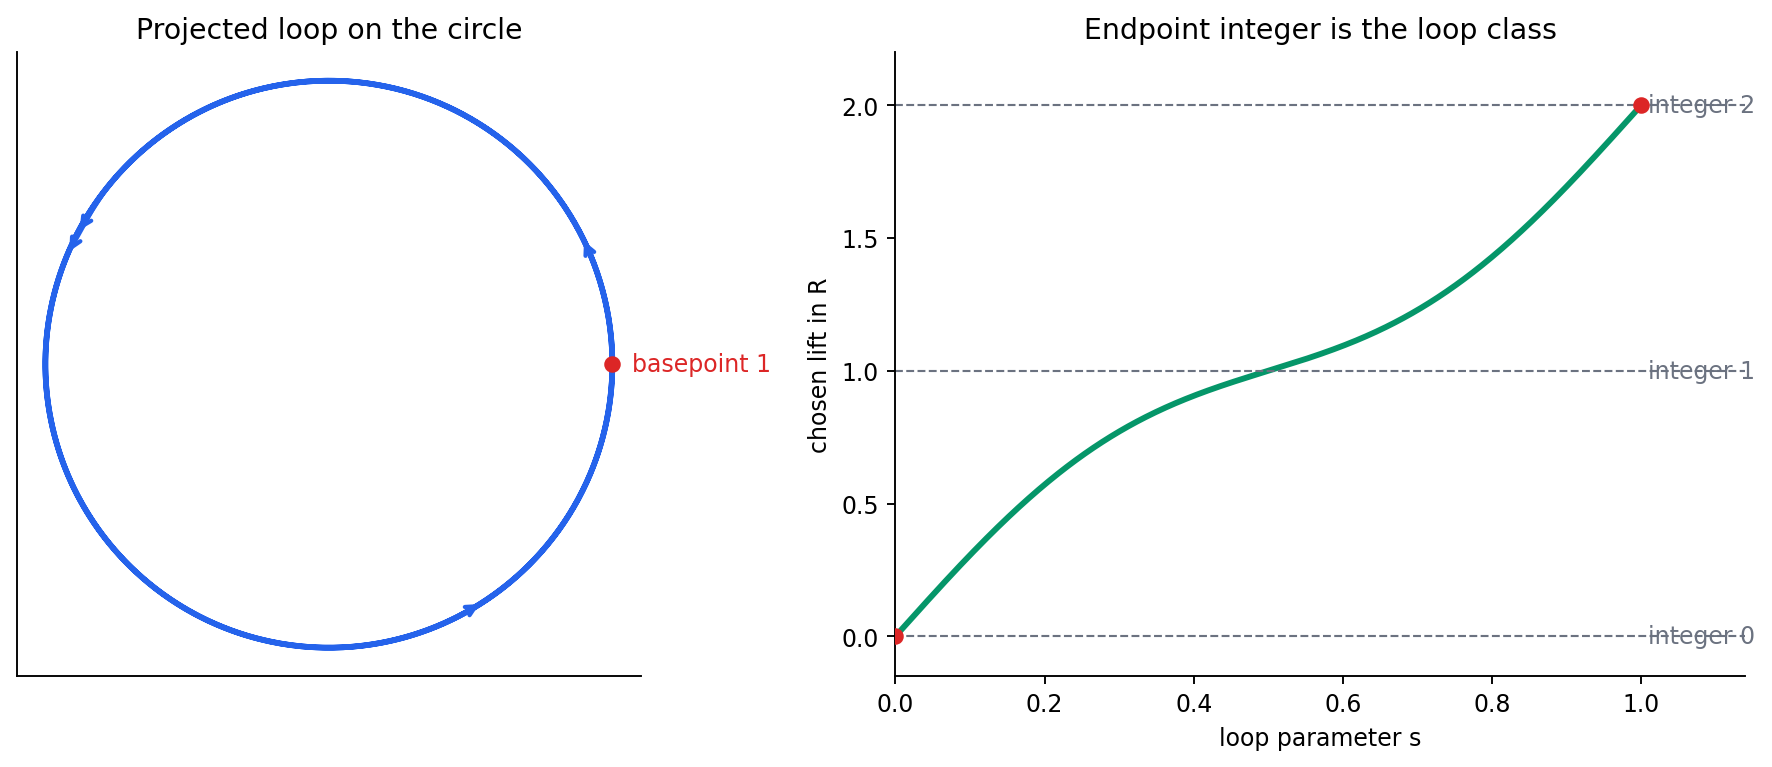

{'lift_endpoint_integer': 2,
 'computed_winding_number': 2,
 'endpoint_matches_winding': True}

In [7]:
t = np.linspace(0, 1, 600)
lift = 2 * t + .18 * np.sin(2 * np.pi * t)
circle_points = np.column_stack([np.cos(2 * np.pi * lift), np.sin(2 * np.pi * lift)])
lift_degree = int(round(lift[-1] - lift[0]))
computed_circle_degree = winding_number(circle_points)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
ax = axes[0]
ax.set_aspect("equal")
ax.plot(circle_points[:, 0], circle_points[:, 1], color=PALETTE["blue"], lw=2.4)
ax.add_patch(patches.Circle((0, 0), 1, fill=False, color=PALETTE["muted"], lw=1.2, ls="--"))
ax.scatter([1], [0], color=PALETTE["red"], zorder=5)
for idx in [80, 200, 340, 470]:
    ax.annotate("", xy=circle_points[idx + 8], xytext=circle_points[idx], arrowprops={"arrowstyle": "->", "color": PALETTE["blue"], "lw": 1.8})
ax.set_title("Projected loop on the circle"); ax.set_xticks([]); ax.set_yticks([])
ax.text(1.07, 0, "basepoint 1", va="center", color=PALETTE["red"])
ax = axes[1]
ax.plot(t, lift, color=PALETTE["green"], lw=2.5)
for k in range(3):
    ax.axhline(k, color=PALETTE["muted"], lw=.9, ls="--")
    ax.text(1.01, k, f"integer {k}", va="center", color=PALETTE["muted"])
ax.scatter([0, 1], [lift[0], lift[-1]], color=PALETTE["red"], zorder=5)
ax.set(xlabel="loop parameter s", ylabel="chosen lift in R", title="Endpoint integer is the loop class", xlim=(0, 1.14), ylim=(-.15, 2.2))
circle_lift_path = save_registered_matplotlib(fig, "circle-lift-degree.png")

fig3d = go.Figure()
for degree in [-1, 0, 1, 2, 3]:
    tt = np.linspace(0, 1, 320)
    lifted = degree * tt
    fig3d.add_trace(go.Scatter3d(x=np.cos(2*np.pi*lifted), y=np.sin(2*np.pi*lifted), z=lifted, mode="lines", line={"width":5}, name=f"degree {degree}", customdata=tt, hovertemplate="s=%{customdata:.2f}<br>lift=%{z:.2f}<extra></extra>"))
fig3d.update_layout(title="Circle loops as lifted helices over S^1", scene={"xaxis_title":"cos(2pi theta)", "yaxis_title":"sin(2pi theta)", "zaxis_title":"lift theta", "aspectmode":"cube"}, margin={"l":0,"r":0,"t":45,"b":0}, legend={"orientation":"h","y":-.05})
circle_cover_html = register(save_plotly_html(fig3d, UNIT, "html", "circle-covering-degree-lab.html"))
circle_lift_checks = {"lift_endpoint_integer": lift_degree, "computed_winding_number": computed_circle_degree, "endpoint_matches_winding": lift_degree == computed_circle_degree == 2}
display_artifact(circle_lift_path, width=920)
display_artifact(circle_cover_html, width="100%", height=520)
circle_lift_checks


## Wedge Of Circles: The Free Group View

For a one-point union of two circles, a loop records a word in two generators. There is no surface relation yet, so the only simplification is immediate cancellation such as `a A` or `B b`. This is the computational reason the figure-eight group is free on two generators.

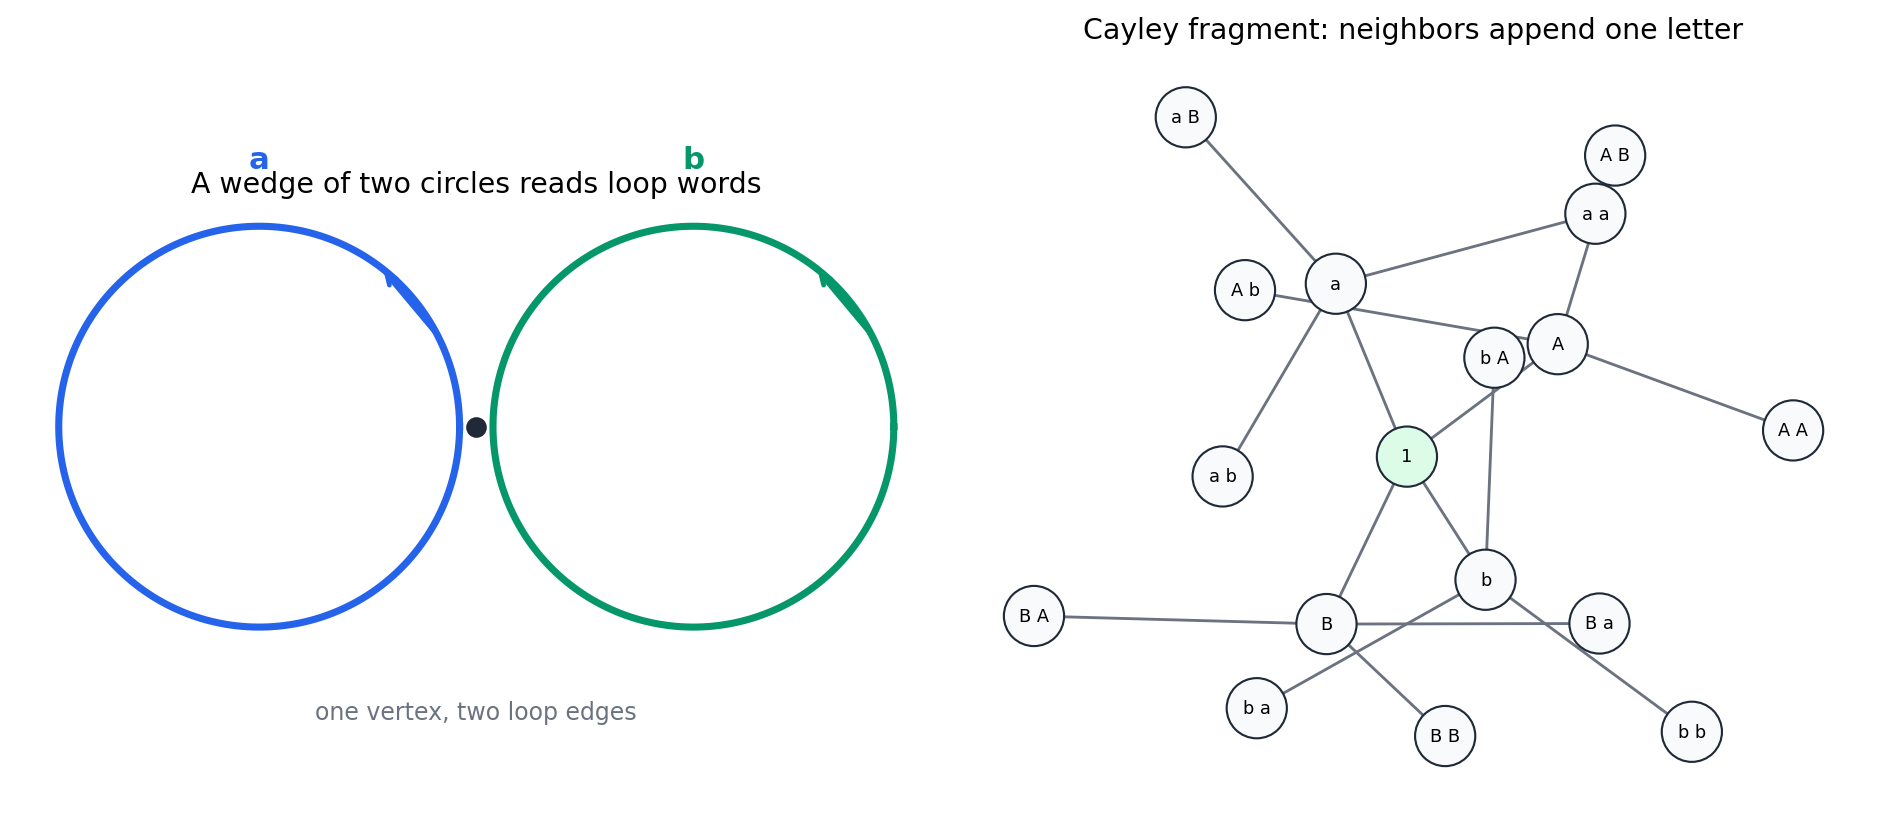

,input_word,free_reduction,length_before,length_after,exponent_a,exponent_b,reduction_idempotent
0,a b B A,1,4,0,0,0,True
1,a b A B,a b A B,4,4,0,0,True
2,a a B b A,a,5,1,1,0,True
3,a b A a B b,a b,6,2,1,1,True
4,a b b A B a A,a b b A B,7,5,0,1,True


{'all_reductions_idempotent': True,
 'identity_example_reduces_to_empty': True,
 'cayley_nodes_radius_2': 17}

In [8]:
def cayley_fragment(generators=("a", "b"), radius=2):
    start = tuple(); seen = {start}; queue = deque([(start, 0)]); graph = nx.Graph(); graph.add_node(start)
    letters = list(generators) + [g.upper() for g in generators]
    while queue:
        word, depth = queue.popleft()
        if depth == radius:
            continue
        for letter in letters:
            new_word = reduce_word(word + (letter,))
            graph.add_edge(word, new_word, label=letter.lower())
            if new_word not in seen:
                seen.add(new_word); queue.append((new_word, depth + 1))
    return graph

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7), constrained_layout=True)
ax = axes[0]
ax.set_aspect("equal"); ax.axis("off")
angles = np.linspace(0, 2*np.pi, 240)
left = np.column_stack([-.52 + .48*np.cos(angles), .48*np.sin(angles)])
right = np.column_stack([.52 + .48*np.cos(angles), .48*np.sin(angles)])
ax.plot(left[:,0], left[:,1], color=PALETTE["blue"], lw=3)
ax.plot(right[:,0], right[:,1], color=PALETTE["green"], lw=3)
ax.scatter([0], [0], color=PALETTE["ink"], s=60, zorder=5)
ax.annotate("", xy=left[35], xytext=left[18], arrowprops={"arrowstyle":"->", "color":PALETTE["blue"], "lw":2})
ax.annotate("", xy=right[35], xytext=right[18], arrowprops={"arrowstyle":"->", "color":PALETTE["green"], "lw":2})
ax.text(-.52, .62, "a", color=PALETTE["blue"], ha="center", weight="bold", fontsize=13)
ax.text(.52, .62, "b", color=PALETTE["green"], ha="center", weight="bold", fontsize=13)
ax.text(0, -.7, "one vertex, two loop edges", ha="center", color=PALETTE["muted"])
ax.set_title("A wedge of two circles reads loop words")
ax = axes[1]
fragment = cayley_fragment(radius=2)
layout = nx.spring_layout(fragment, seed=7, k=.75)
node_labels = {node: word_to_string(node) for node in fragment.nodes}
node_colors = [PALETTE["light_green"] if len(node) == 0 else PALETTE["panel"] for node in fragment.nodes]
nx.draw_networkx_nodes(fragment, layout, node_size=650, node_color=node_colors, edgecolors=PALETTE["ink"], linewidths=.9, ax=ax)
nx.draw_networkx_edges(fragment, layout, width=1.2, edge_color=PALETTE["muted"], ax=ax)
nx.draw_networkx_labels(fragment, layout, labels=node_labels, font_size=7.5, ax=ax)
ax.set_title("Cayley fragment: neighbors append one letter"); ax.axis("off")
wedge_path = save_registered_matplotlib(fig, "wedge-free-group-cayley.png")

candidate_words = ["a b B A", "a b A B", "a a B b A", "a b A a B b", "a b b A B a A"]
word_rows = []
for text in candidate_words:
    word = parse_word(text); reduced = reduce_word(word); exp_a, exp_b = exponent_vector(word, ("a", "b"))
    word_rows.append({"input_word": text, "free_reduction": word_to_string(reduced), "length_before": len(word), "length_after": len(reduced), "exponent_a": exp_a, "exponent_b": exp_b, "reduction_idempotent": reduce_word(reduced) == reduced})
word_df = pd.DataFrame(word_rows)
word_table_path = register(artifact_path(UNIT, "tables", "free-word-reductions.csv"))
word_df.to_csv(word_table_path, index=False)
free_group_checks = {"all_reductions_idempotent": bool(word_df["reduction_idempotent"].all()), "identity_example_reduces_to_empty": reduce_word(parse_word("a b B A")) == tuple(), "cayley_nodes_radius_2": fragment.number_of_nodes()}
display_artifact(wedge_path, width=920)
display(word_df)
display_artifact(word_table_path)
free_group_checks


## Surface-Friendly Computations

Surface examples add geometric ways to get generators and relations. The torus has a meridian and a longitude; an annulus or cylinder deformation-retracts to a circle; polygon side identifications encode relators before later chapters give a broader computation method.

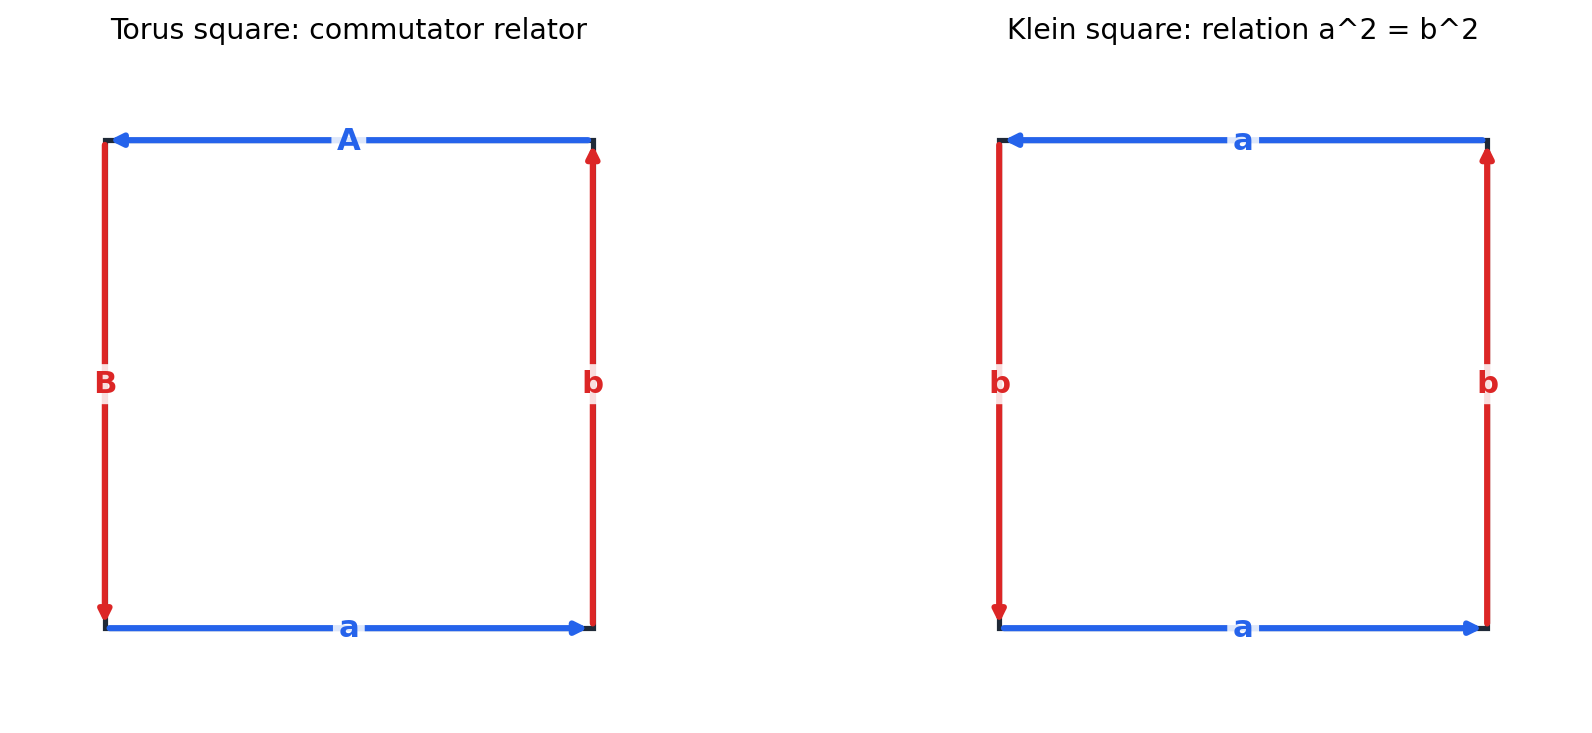

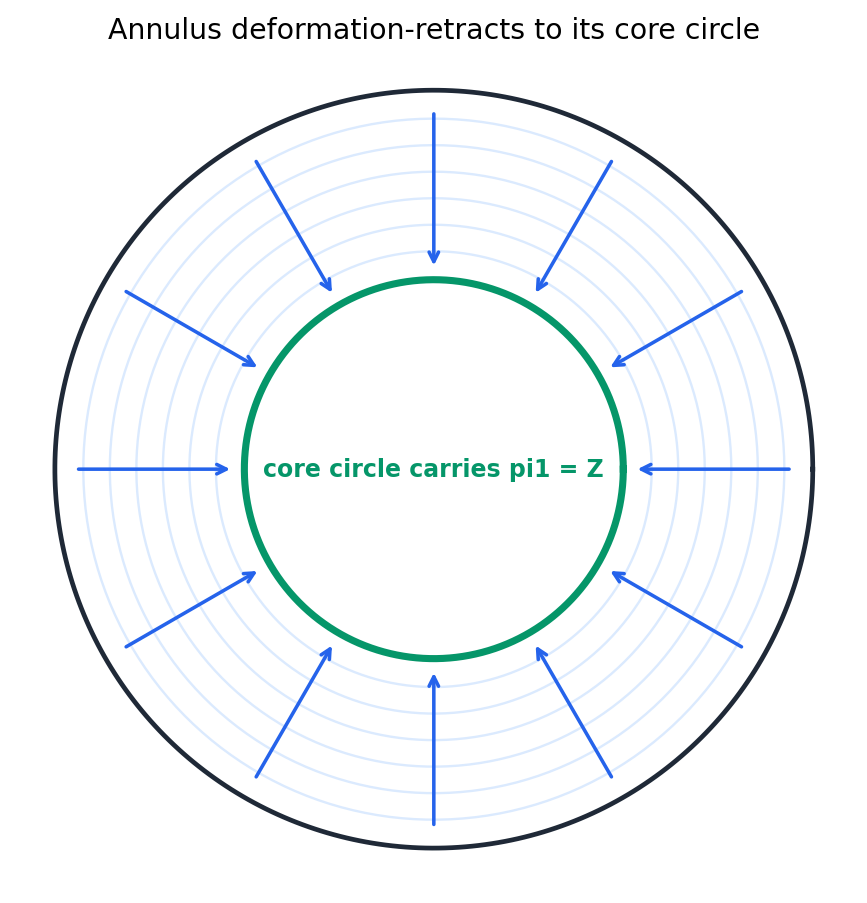

In [9]:
u = np.linspace(0, 2*np.pi, 90); v = np.linspace(0, 2*np.pi, 45)
U, V = np.meshgrid(u, v); R, r = 2.1, .55
X = (R + r*np.cos(V))*np.cos(U); Y = (R + r*np.cos(V))*np.sin(U); Z = r*np.sin(V)
fig_torus = go.Figure()
fig_torus.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale="Viridis", opacity=.62, showscale=False, name="torus"))
fig_torus.add_trace(go.Scatter3d(x=(R+r)*np.cos(u), y=(R+r)*np.sin(u), z=np.zeros_like(u), mode="lines", line={"color":"#2563eb", "width":7}, name="longitude a"))
mu = np.pi/4
fig_torus.add_trace(go.Scatter3d(x=(R+r*np.cos(v))*np.cos(mu), y=(R+r*np.cos(v))*np.sin(mu), z=r*np.sin(v), mode="lines", line={"color":"#dc2626", "width":7}, name="meridian b"))
fig_torus.update_layout(title="Torus generators: longitude and meridian", scene={"xaxis_visible":False,"yaxis_visible":False,"zaxis_visible":False,"aspectmode":"data"}, margin={"l":0,"r":0,"t":45,"b":0})
torus_html = register(save_plotly_html(fig_torus, UNIT, "html", "torus-generators.html"))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
for ax, title, labels in [(axes[0], "Torus square: commutator relator", ["a", "b", "A", "B"]), (axes[1], "Klein square: relation a^2 = b^2", ["a", "b", "a", "b"])]:
    ax.set_aspect("equal"); ax.axis("off")
    ax.add_patch(patches.Rectangle((0, 0), 1, 1, fill=False, lw=2.2, color=PALETTE["ink"]))
    edge_data = [((0,0),(1,0)), ((1,0),(1,1)), ((1,1),(0,1)), ((0,1),(0,0))]
    for (start, end), label in zip(edge_data, labels):
        color = PALETTE["blue"] if label.lower() == "a" else PALETTE["red"]
        ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle":"-|>", "lw":2.6, "color":color})
        mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
        ax.text(mx, my, label, color=color, fontsize=13, weight="bold", ha="center", va="center", bbox={"boxstyle":"round,pad=0.18", "facecolor":"white", "edgecolor":"none", "alpha":.85})
    ax.set_xlim(-.18, 1.18); ax.set_ylim(-.18, 1.18); ax.set_title(title)
surface_polygon_path = save_registered_matplotlib(fig, "surface-generator-polygons.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2), constrained_layout=True)
ax.set_aspect("equal"); ax.axis("off")
theta = np.linspace(0, 2*np.pi, 360)
for radius, style in [(1.0, "-"), (2.0, "-")]:
    ax.plot(radius*np.cos(theta), radius*np.sin(theta), color=PALETTE["ink"], lw=2, ls=style)
for radius in np.linspace(1.15, 1.85, 6):
    ax.plot(radius*np.cos(theta), radius*np.sin(theta), color=PALETTE["light_blue"], lw=1)
for angle in np.linspace(0, 2*np.pi, 12, endpoint=False):
    ax.annotate("", xy=(1.05*np.cos(angle), 1.05*np.sin(angle)), xytext=(1.9*np.cos(angle), 1.9*np.sin(angle)), arrowprops={"arrowstyle":"->", "color":PALETTE["blue"], "lw":1.5})
ax.plot(1.0*np.cos(theta), 1.0*np.sin(theta), color=PALETTE["green"], lw=3)
ax.text(0, 0, "core circle carries pi1 = Z", ha="center", va="center", color=PALETTE["green"], weight="bold")
ax.set_title("Annulus deformation-retracts to its core circle")
annulus_path = save_registered_matplotlib(fig, "deformation-retraction-annulus.png")
display_artifact(torus_html, width="100%", height=520)
display_artifact(surface_polygon_path, width=900)
display_artifact(annulus_path, width=620)


## Group Presentation Checks

The presentation ledger is not a full group-isomorphism prover. It is a disciplined check that each relator has the expected abelian shadow. This catches wrong exponents in circle, torus, Klein, projective-plane, and lens-space examples.

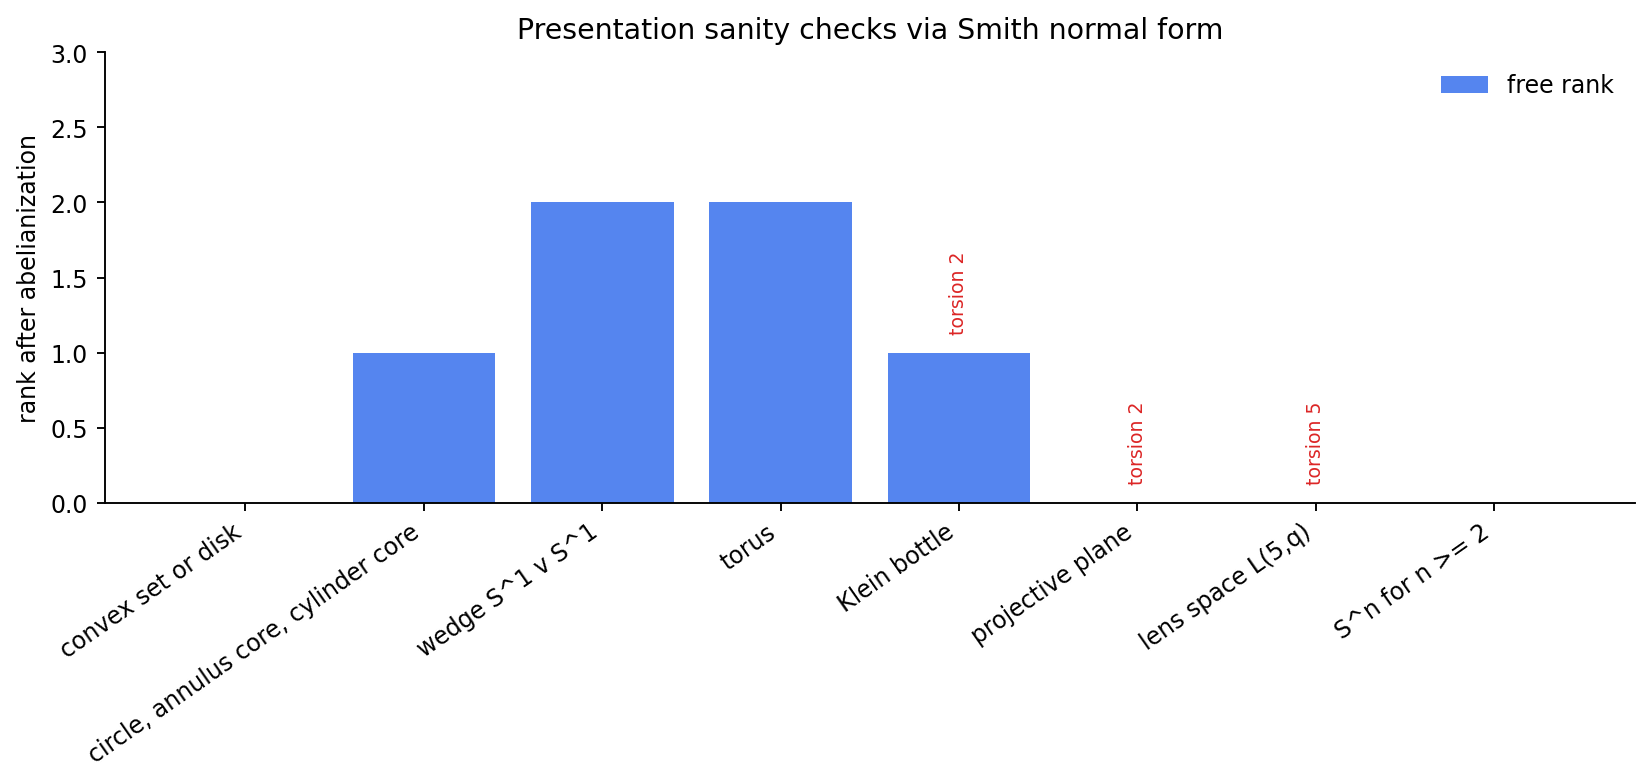

,space,generators,relators,abelianization_rank,abelianization_torsion,abelianization_readout,expected_sanity_target
0,convex set or disk,none,none,0,none,0,0
1,"circle, annulus core, cylinder core",a,none,1,none,Z,Z
2,wedge S^1 v S^1,a.b,none,2,none,Z^2,Z^2 after abelianization
3,torus,a.b,a b A B,2,none,Z^2,Z^2
4,Klein bottle,a.b,a a B B,1,2,Z x Z/2,Z x Z/2 after abelianization
5,projective plane,a,a a,0,2,Z/2,Z/2
6,"lens space L(5,q)",a,a a a a a,0,5,Z/5,Z/5
7,S^n for n >= 2,none,none,0,none,0,0


{'torus_rank_two': True,
 'projective_plane_has_order_two_abelianization': True,
 'lens_space_order_five_check': True,
 'klein_abelianization_has_one_free_and_one_order_two': True}

In [10]:
presentation_specs = [
    {"space":"convex set or disk", "generators":[], "relators":[], "expected":"0"},
    {"space":"circle, annulus core, cylinder core", "generators":["a"], "relators":[], "expected":"Z"},
    {"space":"wedge S^1 v S^1", "generators":["a","b"], "relators":[], "expected":"Z^2 after abelianization"},
    {"space":"torus", "generators":["a","b"], "relators":[parse_word("a b A B")], "expected":"Z^2"},
    {"space":"Klein bottle", "generators":["a","b"], "relators":[parse_word("a a B B")], "expected":"Z x Z/2 after abelianization"},
    {"space":"projective plane", "generators":["a"], "relators":[parse_word("a a")], "expected":"Z/2"},
    {"space":"lens space L(5,q)", "generators":["a"], "relators":[tuple("a" for _ in range(5))], "expected":"Z/5"},
    {"space":"S^n for n >= 2", "generators":[], "relators":[], "expected":"0"},
]
presentation_rows, presentation_checks = [], {}
for spec in presentation_specs:
    summary = abelianization_summary(spec["generators"], spec["relators"])
    relator_text = "; ".join(word_to_string(r) for r in spec["relators"]) if spec["relators"] else "none"
    presentation_rows.append({"space":spec["space"], "generators":".".join(spec["generators"]) if spec["generators"] else "none", "relators":relator_text, "abelianization_rank":summary["rank"], "abelianization_torsion":".".join(map(str, summary["torsion"])) if summary["torsion"] else "none", "abelianization_readout":describe_abelianization(summary), "expected_sanity_target":spec["expected"]})
    presentation_checks[spec["space"]] = summary
presentation_df = pd.DataFrame(presentation_rows)
presentation_table_path = register(artifact_path(UNIT, "tables", "presentation-invariants.csv"))
presentation_df.to_csv(presentation_table_path, index=False)

fig, ax = plt.subplots(figsize=(9.6, 4.5), constrained_layout=True)
bar_x = np.arange(len(presentation_df))
ax.bar(bar_x, presentation_df["abelianization_rank"], color=PALETTE["blue"], alpha=.78, label="free rank")
for i, torsion_text in enumerate(presentation_df["abelianization_torsion"]):
    if torsion_text != "none":
        ax.text(i, presentation_df.loc[i, "abelianization_rank"] + .12, f"torsion {torsion_text}", rotation=90, ha="center", va="bottom", fontsize=8, color=PALETTE["red"])
ax.set_xticks(bar_x); ax.set_xticklabels(presentation_df["space"], rotation=35, ha="right")
ax.set_ylabel("rank after abelianization"); ax.set_title("Presentation sanity checks via Smith normal form")
ax.set_ylim(0, max(2.6, presentation_df["abelianization_rank"].max() + 1)); ax.legend(frameon=False)
presentation_chart_path = save_registered_matplotlib(fig, "presentation-abelianization-checks.png")
surface_presentation_checks = {
    "torus_rank_two": presentation_checks["torus"]["rank"] == 2,
    "projective_plane_has_order_two_abelianization": presentation_checks["projective plane"]["torsion"] == [2],
    "lens_space_order_five_check": presentation_checks["lens space L(5,q)"]["torsion"] == [5],
    "klein_abelianization_has_one_free_and_one_order_two": presentation_checks["Klein bottle"]["rank"] == 1 and presentation_checks["Klein bottle"]["torsion"] == [2],
}
display_artifact(presentation_chart_path, width=900)
display(presentation_df)
display_artifact(presentation_table_path)
surface_presentation_checks


## Brouwer Fixed-Point Obstruction In Dimension Two

If a fixed-point-free self-map of the disc existed, each point could be sent along the ray from `f(x)` through `x` until it hit the boundary circle. That would be a retraction `D -> S^1`. The group-level obstruction is small but decisive: the boundary inclusion followed by the retraction would have to induce the identity on `Z`, while `pi_1(D)` is trivial.

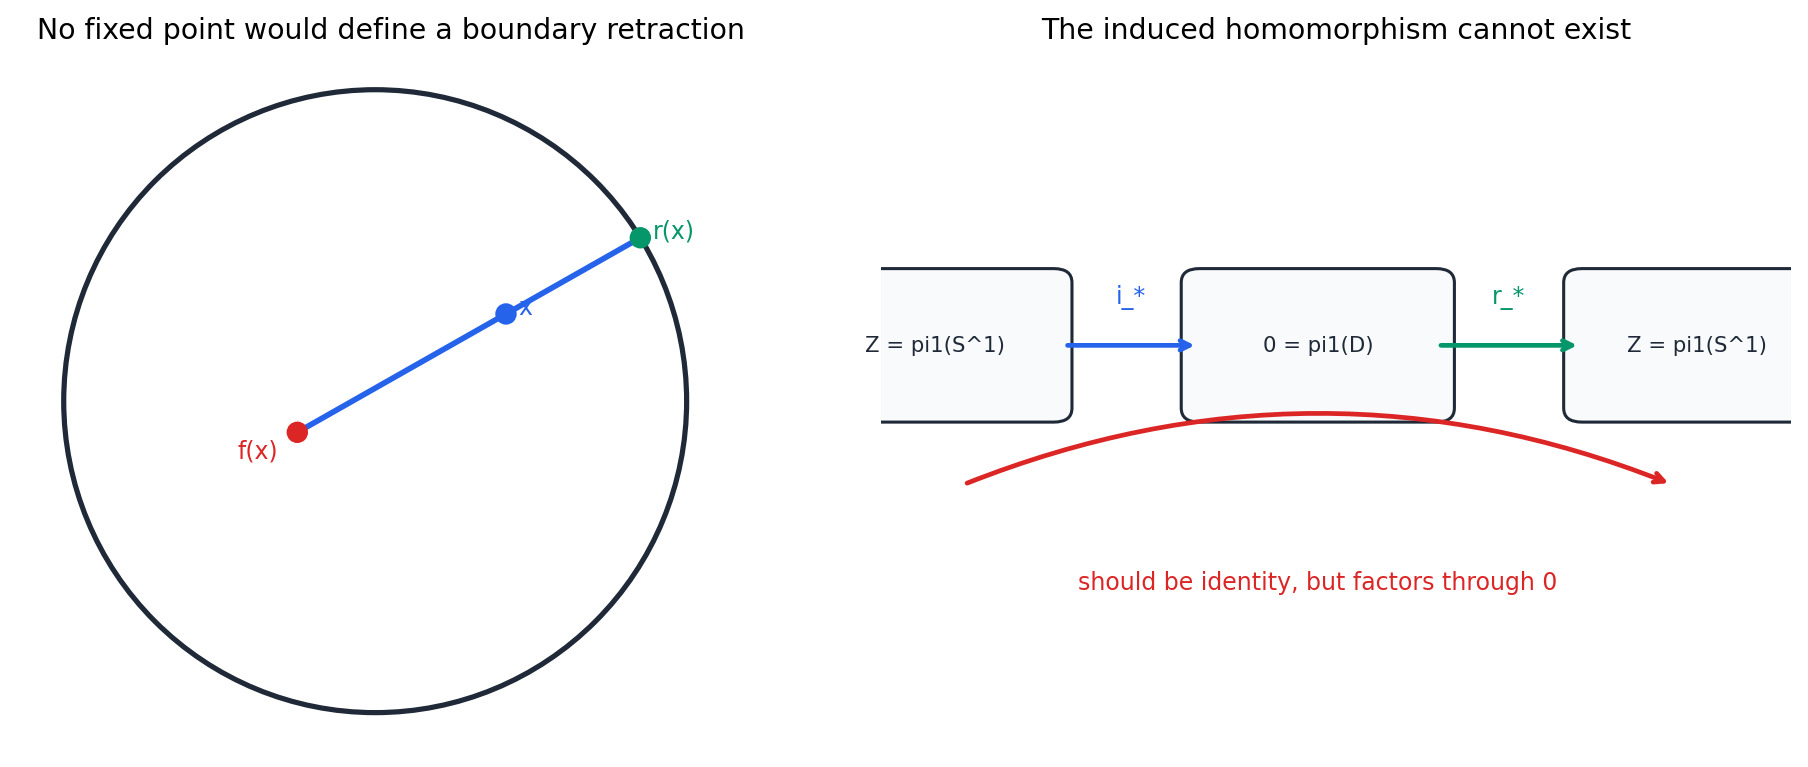

{'boundary_hit_has_unit_norm': True,
 'composition_through_trivial_group': [[0]],
 'composition_is_not_identity_on_Z': True}

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
ax = axes[0]
ax.set_aspect("equal"); ax.axis("off")
ax.add_patch(patches.Circle((0, 0), 1, fill=False, color=PALETTE["ink"], lw=2.2))
fx = np.array([-.25, -.1]); x = np.array([.42, .28]); direction = x - fx
A = np.dot(direction, direction); B = 2*np.dot(fx, direction); C = np.dot(fx, fx) - 1
lambda_hit = float(max(root.real for root in np.roots([A, B, C]) if abs(root.imag) < 1e-9))
hit = fx + lambda_hit * direction
ax.plot([fx[0], hit[0]], [fx[1], hit[1]], color=PALETTE["blue"], lw=2.4)
ax.scatter([fx[0], x[0], hit[0]], [fx[1], x[1], hit[1]], color=[PALETTE["red"], PALETTE["blue"], PALETTE["green"]], s=65, zorder=5)
ax.text(fx[0]-.06, fx[1]-.08, "f(x)", color=PALETTE["red"], ha="right")
ax.text(x[0]+.04, x[1], "x", color=PALETTE["blue"], ha="left")
ax.text(hit[0]+.04, hit[1], "r(x)", color=PALETTE["green"], ha="left")
ax.set_xlim(-1.15, 1.25); ax.set_ylim(-1.12, 1.12); ax.set_title("No fixed point would define a boundary retraction")

ax = axes[1]
ax.axis("off")
positions = {"Z = pi1(S^1)": (.06, .58), "0 = pi1(D)": (.48, .58), "Z = pi1(S^1) ": (.90, .58)}
for label, (px, py) in positions.items():
    ax.add_patch(patches.FancyBboxPatch((px-.13, py-.09), .26, .18, boxstyle="round,pad=0.02", facecolor=PALETTE["panel"], edgecolor=PALETTE["ink"], lw=1.3))
    ax.text(px, py, label, ha="center", va="center", fontsize=9, color=PALETTE["ink"])
ax.annotate("", xy=(.35,.58), xytext=(.20,.58), arrowprops={"arrowstyle":"->", "lw":2, "color":PALETTE["blue"]})
ax.annotate("", xy=(.77,.58), xytext=(.61,.58), arrowprops={"arrowstyle":"->", "lw":2, "color":PALETTE["green"]})
ax.annotate("", xy=(.87,.38), xytext=(.09,.38), arrowprops={"arrowstyle":"->", "lw":2, "color":PALETTE["red"], "connectionstyle":"arc3,rad=-0.2"})
ax.text(.275, .64, "i_*", color=PALETTE["blue"], ha="center")
ax.text(.69, .64, "r_*", color=PALETTE["green"], ha="center")
ax.text(.48, .23, "should be identity, but factors through 0", color=PALETTE["red"], ha="center")
ax.set_title("The induced homomorphism cannot exist")
brouwer_path = save_registered_matplotlib(fig, "brouwer-retraction-obstruction.png")
inclusion_matrix = zeros(0, 1); retraction_matrix = zeros(1, 0); composition_matrix = retraction_matrix * inclusion_matrix
brouwer_checks = {"boundary_hit_has_unit_norm": abs(float(np.linalg.norm(hit)) - 1.0) < 1e-10, "composition_through_trivial_group": [[int(x) for x in row] for row in composition_matrix.tolist()], "composition_is_not_identity_on_Z": composition_matrix != eye(1)}
display_artifact(brouwer_path, width=920)
brouwer_checks


## Separation And Surface Boundary Intuition

The chapter also uses the fundamental group to explain why a closed curve in the plane separates while an arc does not, and why an interior point of a surface cannot also be a boundary point. The first computation samples complement paths on a grid. The second diagram mirrors the boundary argument: a punctured half-disc is contractible, so it cannot retract onto a circle with fundamental group `Z`.

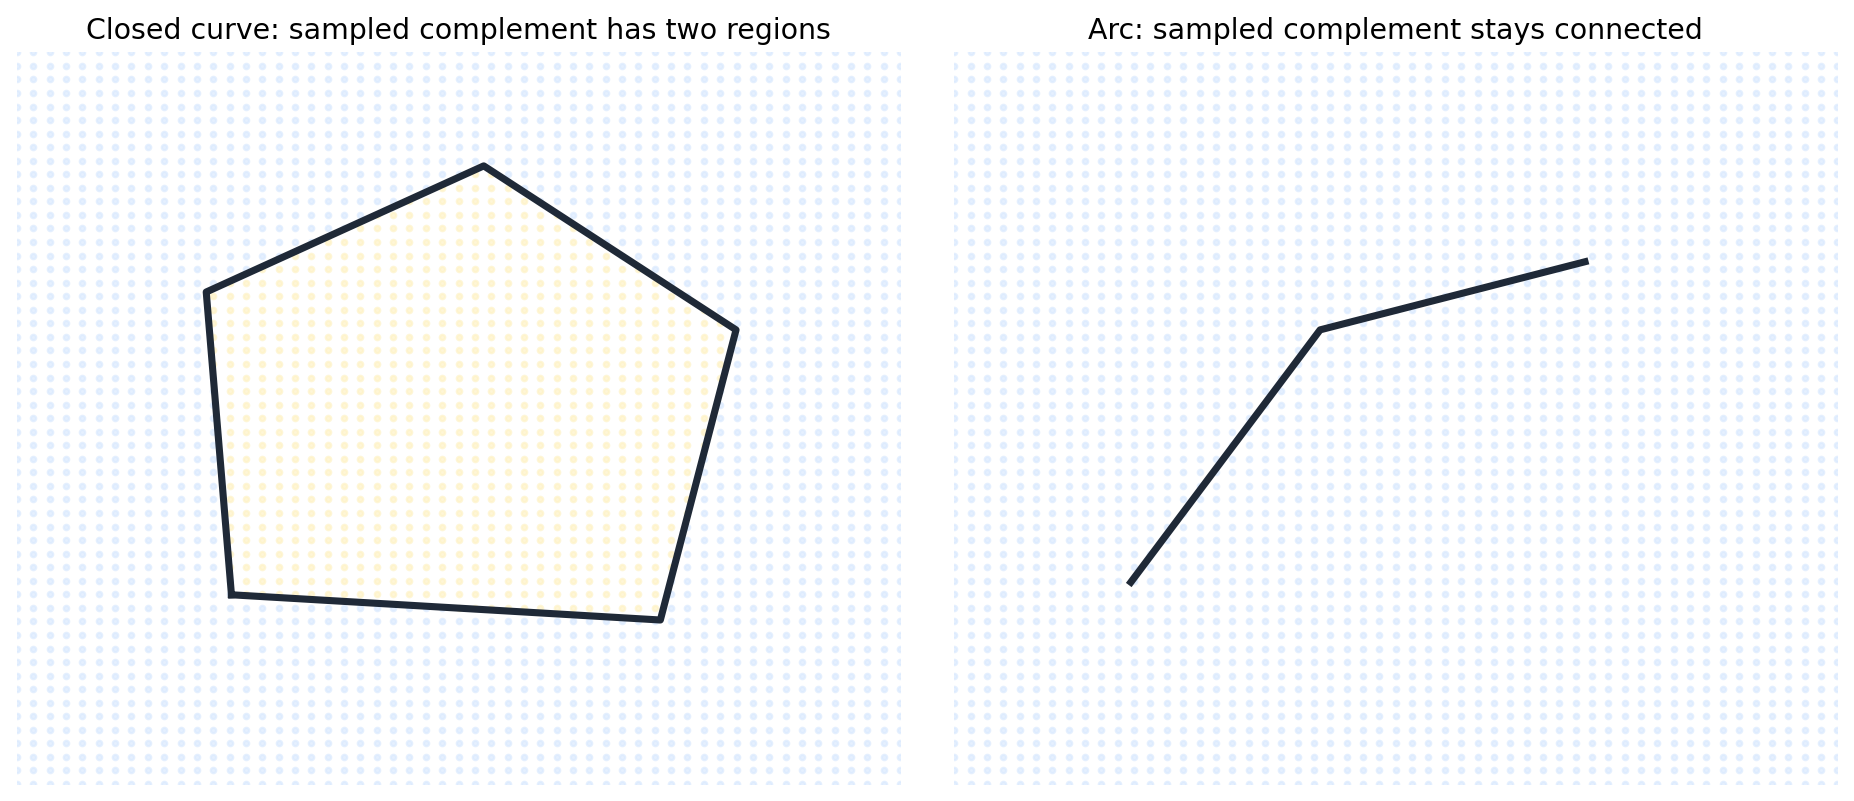

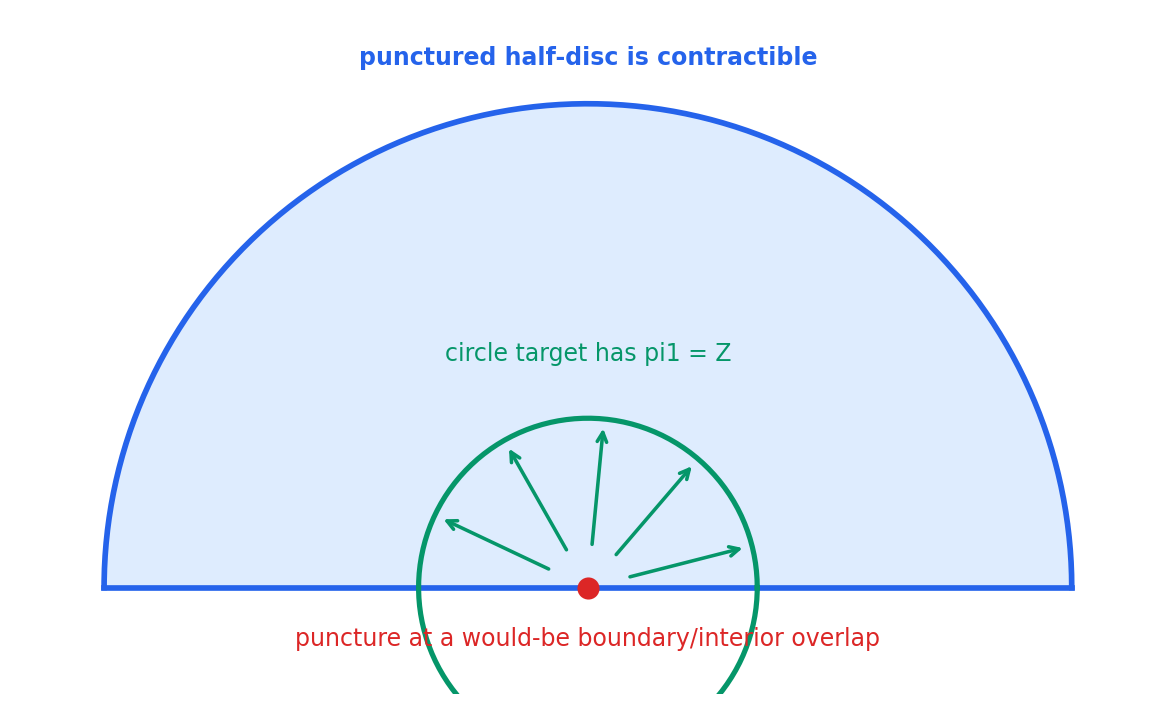

{'polygonal_jordan_sampled_components': 2,
 'polygonal_jordan_component_sizes': [2205, 820],
 'arc_sampled_components': 1,
 'arc_component_sizes': [3025],
 'boundary_obstruction_uses_trivial_to_cyclic_contrast': True}

In [12]:
def sampled_complement_components(curve: LineString, n=55, bounds=(-1.75, 1.75, -1.45, 1.45)):
    xs = np.linspace(bounds[0], bounds[1], n); ys = np.linspace(bounds[2], bounds[3], n)
    graph = nx.Graph()
    for i, x_val in enumerate(xs):
        for j, y_val in enumerate(ys):
            if curve.distance(Point(x_val, y_val)) > 1e-9:
                graph.add_node((i, j), pos=(x_val, y_val))
    for i in range(n):
        for j in range(n):
            if (i, j) not in graph:
                continue
            for di, dj in [(1, 0), (0, 1)]:
                ni, nj = i + di, j + dj
                if (ni, nj) not in graph:
                    continue
                segment = LineString([(xs[i], ys[j]), (xs[ni], ys[nj])])
                if not segment.crosses(curve) and not segment.intersects(curve):
                    graph.add_edge((i, j), (ni, nj))
    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    component_index = {node: idx for idx, component in enumerate(components) for node in component}
    return graph, components, component_index

polygon_curve = LineString([(-.9,-.7), (.8,-.8), (1.1,.35), (.1,1.0), (-1.0,.5), (-.9,-.7)])
arc_curve = LineString([(-1.05,-.65), (-.3,.35), (.75,.62)])
polygon_graph, polygon_components, polygon_component_index = sampled_complement_components(polygon_curve)
arc_graph, arc_components, arc_component_index = sampled_complement_components(arc_curve)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
component_colors = [PALETTE["light_blue"], PALETTE["light_amber"], PALETTE["light_green"], PALETTE["light_red"]]
for ax, graph, components, component_index, curve, title in [(axes[0], polygon_graph, polygon_components, polygon_component_index, polygon_curve, "Closed curve: sampled complement has two regions"), (axes[1], arc_graph, arc_components, arc_component_index, arc_curve, "Arc: sampled complement stays connected")]:
    ax.set_aspect("equal"); ax.axis("off")
    for node, (x_val, y_val) in nx.get_node_attributes(graph, "pos").items():
        ax.scatter(x_val, y_val, s=5, color=component_colors[component_index[node] % len(component_colors)], alpha=.7)
    x_curve, y_curve = curve.xy
    ax.plot(x_curve, y_curve, color=PALETTE["ink"], lw=3)
    ax.set_title(title); ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.45, 1.45)
separation_path = save_registered_matplotlib(fig, "plane-separation-grid-check.png")

fig, ax = plt.subplots(figsize=(6.8, 4.8), constrained_layout=True)
ax.set_aspect("equal"); ax.axis("off")
theta = np.linspace(0, np.pi, 240); outer = np.column_stack([np.cos(theta), np.sin(theta)])
ax.fill_between(outer[:, 0], 0, outer[:, 1], color=PALETTE["light_blue"], alpha=.9)
ax.plot(outer[:, 0], outer[:, 1], color=PALETTE["blue"], lw=2.4); ax.plot([-1, 1], [0, 0], color=PALETTE["blue"], lw=2.4)
ax.scatter([0], [0], s=70, color=PALETTE["red"], zorder=5)
small_theta = np.linspace(0, 2*np.pi, 260)
ax.plot(.35*np.cos(small_theta), .35*np.sin(small_theta), color=PALETTE["green"], lw=2.2)
for angle in np.linspace(.25, 2.7, 5):
    start = np.array([.08*np.cos(angle), .08*np.sin(angle)]); end = np.array([.34*np.cos(angle), .34*np.sin(angle)])
    if end[1] >= 0:
        ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle":"->", "lw":1.5, "color":PALETTE["green"]})
ax.text(0, -.12, "puncture at a would-be boundary/interior overlap", ha="center", color=PALETTE["red"])
ax.text(0, .47, "circle target has pi1 = Z", ha="center", color=PALETTE["green"])
ax.text(0, 1.08, "punctured half-disc is contractible", ha="center", color=PALETTE["blue"], weight="bold")
ax.set_xlim(-1.18, 1.18); ax.set_ylim(-.22, 1.18)
boundary_path = save_registered_matplotlib(fig, "surface-boundary-obstruction.png")
separation_checks = {"polygonal_jordan_sampled_components": len(polygon_components), "polygonal_jordan_component_sizes": [len(c) for c in polygon_components[:3]], "arc_sampled_components": len(arc_components), "arc_component_sizes": [len(c) for c in arc_components[:3]], "boundary_obstruction_uses_trivial_to_cyclic_contrast": True}
display_artifact(separation_path, width=920)
display_artifact(boundary_path, width=680)
separation_checks


## Applied Lab: Edit A Loop Word And Watch The Invariants

The lab uses the same word in three increasingly constrained settings. In the wedge, only free cancellation is allowed. In the circle, the exponent sum is the degree. In a torus abelianization, the two exponent sums survive; in the Klein bottle abelianization, the difference between `a` and `b` is remembered only modulo two. Change the `lab_words` list and rerun the cell to test your own loop descriptions.

,word,free_group_normal_form,circle_degree_if_b_ignored,torus_abelianized_vector,klein_mod_2_marker,is_free_identity
0,a b A B,a b A B,0,"(0, 0)",0,False
1,a a B B,a a B B,2,"(2, -2)",0,False
2,a b b A B a,a b b A B a,1,"(1, 1)",0,False
3,a B a B A b,a B a B A b,1,"(1, -1)",0,False
4,a a a A B b,a a,2,"(2, 0)",0,False


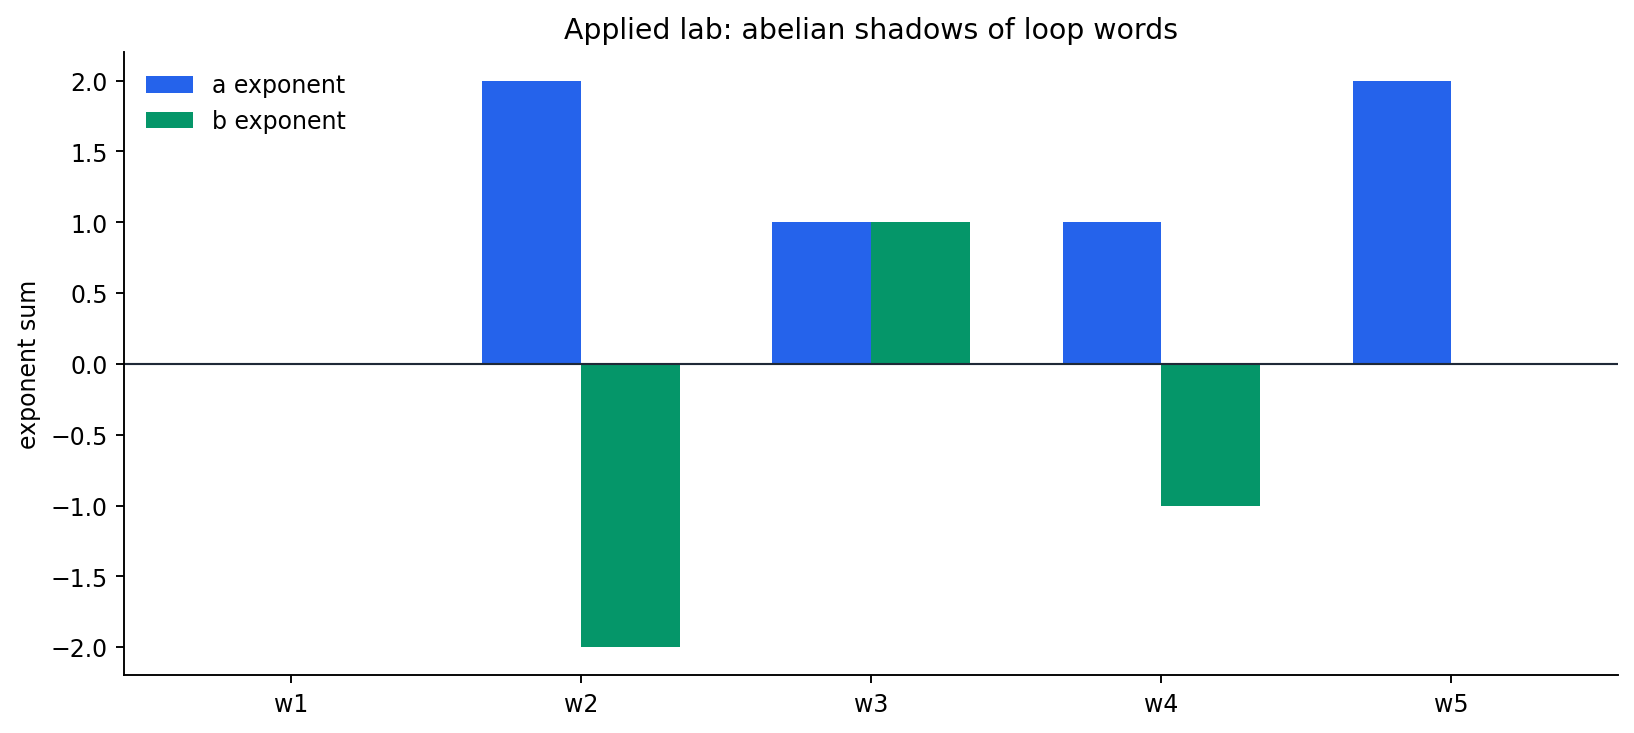

{'rows': 5, 'free_identity_count': 0, 'all_klein_markers_are_mod_2': True}

In [13]:
lab_words = ["a b A B", "a a B B", "a b b A B a", "a B a B A b", "a a a A B b"]
lab_rows = []
for text in lab_words:
    word = parse_word(text); reduced = reduce_word(word); exp_a, exp_b = exponent_vector(word, ("a", "b"))
    lab_rows.append({"word": text, "free_group_normal_form": word_to_string(reduced), "circle_degree_if_b_ignored": exp_a, "torus_abelianized_vector": f"({exp_a}, {exp_b})", "klein_mod_2_marker": (exp_a - exp_b) % 2, "is_free_identity": reduced == tuple()})
lab_df = pd.DataFrame(lab_rows)
lab_table_path = register(artifact_path(UNIT, "tables", "applied-lab-loop-words.csv"))
lab_df.to_csv(lab_table_path, index=False)
fig, ax = plt.subplots(figsize=(9.5, 4.2), constrained_layout=True)
xs = np.arange(len(lab_df)); ax.axhline(0, color=PALETTE["ink"], lw=.9)
ax.bar(xs-.17, [exponent_vector(parse_word(w), ("a","b"))[0] for w in lab_words], width=.34, color=PALETTE["blue"], label="a exponent")
ax.bar(xs+.17, [exponent_vector(parse_word(w), ("a","b"))[1] for w in lab_words], width=.34, color=PALETTE["green"], label="b exponent")
ax.set_xticks(xs); ax.set_xticklabels([f"w{i+1}" for i in range(len(lab_words))]); ax.set_ylabel("exponent sum")
ax.set_title("Applied lab: abelian shadows of loop words"); ax.legend(frameon=False)
lab_chart_path = save_registered_matplotlib(fig, "applied-lab-loop-word-invariants.png")
lab_checks = {"rows": len(lab_df), "free_identity_count": int(lab_df["is_free_identity"].sum()), "all_klein_markers_are_mod_2": all(value in {0, 1} for value in lab_df["klein_mod_2_marker"])}
display(lab_df)
display_artifact(lab_table_path)
display_artifact(lab_chart_path, width=880)
lab_checks


## Sanity Checks

The checks below are intentionally mixed: geometric file checks, numerical degree checks, symbolic presentation checks, and sampled topological checks. Together they guard the main claims of the notebook rather than just confirming that plots were created.

In [14]:
all_checks = {"source_span": SOURCE_SPAN, "loop_degree_checks": loop_degree_checks, "group_law_checks": group_law_checks, "basepoint_induced_checks": basepoint_induced_checks, "circle_lift_checks": circle_lift_checks, "free_group_checks": free_group_checks, "surface_presentation_checks": surface_presentation_checks, "brouwer_checks": brouwer_checks, "separation_checks": separation_checks, "lab_checks": lab_checks}
assert loop_degree_checks["alpha_forward_forward_backward"] == loop_degree_checks["beta_single_forward"] == 1
assert group_law_checks["associativity_words_match"] and group_law_checks["inverse_backtracking_reduces_to_identity"]
assert all(row["homomorphism_composition_ok"] for row in basepoint_induced_checks["degree_map_checks"])
assert circle_lift_checks["endpoint_matches_winding"]
assert free_group_checks["all_reductions_idempotent"]
assert surface_presentation_checks["torus_rank_two"]
assert surface_presentation_checks["projective_plane_has_order_two_abelianization"]
assert surface_presentation_checks["lens_space_order_five_check"]
assert surface_presentation_checks["klein_abelianization_has_one_free_and_one_order_two"]
assert brouwer_checks["boundary_hit_has_unit_norm"] and brouwer_checks["composition_is_not_identity_on_Z"]
assert separation_checks["polygonal_jordan_sampled_components"] == 2 and separation_checks["arc_sampled_components"] == 1
assert lab_checks["all_klein_markers_are_mod_2"]
artifact_sizes = {}
for path in sorted(set(Path(p) for p in artifact_paths)):
    min_bytes = 64 if path.suffix.lower() in {".csv", ".json"} else 512
    assert_artifact(path, min_bytes=min_bytes)
    artifact_sizes[book_rel(path)] = path.stat().st_size
all_checks["artifact_sizes"] = artifact_sizes
checks_path = register(save_json(all_checks, UNIT, "checks", "sanity-checks.json"))
assert_artifact(checks_path, min_bytes=512)
print(f"Validated {len(artifact_sizes)} generated artifacts before writing the check summary.")
display_artifact(checks_path)
all_checks


Validated 18 generated artifacts before writing the check summary.


{'source_span': {'printed': '87-118', 'pdf': '98-128'},
 'loop_degree_checks': {'alpha_forward_forward_backward': 1,
  'beta_single_forward': 1},
 'group_law_checks': {'associativity_words_match': True,
  'inverse_backtracking_reduces_to_identity': True,
  'identity_left': True},
 'basepoint_induced_checks': {'loop_at_old_basepoint': 'a b A',
  'conjugated_loop_at_new_basepoint': 'U a b A u',
  'degree_map_checks': [{'first_map_degree': -2,
    'second_map_degree': 3,
    'composition_degree': -6,
    'homomorphism_composition_ok': True},
   {'first_map_degree': 2,
    'second_map_degree': 5,
    'composition_degree': 10,
    'homomorphism_composition_ok': True},
   {'first_map_degree': 0,
    'second_map_degree': 7,
    'composition_degree': 0,
    'homomorphism_composition_ok': True},
   {'first_map_degree': 1,
    'second_map_degree': -4,
    'composition_degree': -4,
    'homomorphism_composition_ok': True}]},
 'circle_lift_checks': {'lift_endpoint_integer': 2,
  'computed_winding_

## Takeaways

1. The fundamental group is the group of based loops after homotopy rel endpoints, not the set of raw loops.
2. Basepoints matter at the point-set level; in a path-connected space, changing basepoint conjugates loop classes and gives an isomorphic group.
3. The circle calculation is the model: lift a loop to the covering line and read the endpoint integer.
4. Wedges produce free groups; surfaces and orbit spaces add relators that can be checked through presentations and abelianization.
5. Brouwer's fixed-point theorem for the disc, plane separation, and the boundary/interior distinction for surfaces all use the same obstruction pattern: a geometrically tempting retraction would force an impossible map on `pi_1`.
